In [1]:
from utils.visualization import *
from geometry.importers import STEPImporter
from solvers.frequency_domain import FrequencyDomainSolver
from rom.reduction import ModelOrderReduction
from analytical.rectangular_waveguide import RWGAnalytical
from ngsolve.webgui import Draw # must import Draw, otherwise may run into problems showing mesh
from utils.visualization import (
    plot_z_comparison, 
    plot_s_comparison, 
    plot_all_parameters,
    plot_eigenfrequencies,
    ParameterPlotter,
    EigenfrequencyPlotter
)
%matplotlib widget
plt.rcParams['figure.dpi'] = 100

## 1. Define Geometry

Create a circular waveguide with specified dimensions and mesh parameters.

In [2]:
class Models:
    def rwg(self, maxh=0.04):
        geo = STEPImporter(r"../rwg/rectangular_waveguide.step", auto_build=False)
        geo.build()
        geo.name_solids()
        geo.generate_mesh(maxh)
        return geo
    def rwg_split(self, maxh=0.04):
        geo = STEPImporter(r"../rwg/rectangular_waveguide.step", auto_build=False)
        geo.add_splitting_plane_at_z(0.05)
        geo.add_splitting_plane_at_z(0.10)
        geo.split()
        geo.show_split_preview()
        geo.build()
        geo.name_solids()

        geo.generate_mesh(maxh=0.03) # after naming solids, must generate mesh but avoid rebuilding
        return geo
    def cwg(self, maxh=0.04):
        geo = STEPImporter(r"circular_waveguide.step", auto_build=False)
        geo.build()
        geo.name_solids()
        geo.generate_mesh(maxh)
        return geo
    def cwg_split(self, maxh=0.04):
        geo = STEPImporter(r"circular_waveguide.step", auto_build=False)
        geo.add_splitting_plane_at_z(0.075)
        geo.add_splitting_plane_at_z(0.15)
        geo.split()

        geo.show_split_preview()
        geo.build()
        geo.name_solids()

        geo.generate_mesh(maxh=0.04) # after naming solids, must generate mesh but avoid rebuilding
        return geo

In [3]:
models = Models()
geo = models.cwg_split()
print(geo.mesh.GetBoundaries())
geo.show('mesh')

Named 3 solids, 4 ports
  External: port1, port4
  Internal: port2, port3
Displayed 3 solids with distinct colors
Displayed 2 splitting plane(s)


Named 3 solids, 4 ports
  External: port1, port4
  Internal: port2, port3
('wall', 'port3', 'port4', 'wall', 'port2', 'wall', 'port1')


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

In [4]:
fmin, fmax, nsamples = 0.1, 3, 100
fds = FrequencyDomainSolver(geo, order=3)


Structure Topology
Type: Compound structure
Domains (3): ['cell_1', 'cell_2', 'cell_3']
Total Ports (4): ['port1', 'port2', 'port3', 'port4']
External Ports (2): ['port1', 'port4']
Internal Ports (2): ['port2', 'port3']

Domain-Port Mapping:
  cell_1: ['port1 (external, input)', 'port2 (internal)']
  cell_2: ['port2 (internal)', 'port3 (internal)']
  cell_3: ['port3 (internal)', 'port4 (external, output)']


In [5]:
fds.assemble_matrices(nportmodes=3)
%time result = fds.solve(fmin, fmax, nsamples, solver_type='direct')


Assembling Matrices...

Solving port eigenmodes...

	Calculating Port Eigenmodes...
	  Mode source: analytic
	  Polarization angle: 0.0°
	  Requested modes per port: 3
	------------------------------------------------------------
	  port3: circular (fit error: 0.0000)
	    R=0.150001
	  port4: circular (fit error: 0.0000)
	    R=0.150001
	  port2: circular (fit error: 0.0000)
	    R=0.150001
	  port1: circular (fit error: 0.0000)
	    R=0.150001
	  Precomputing boundary mass matrices (once per port)...
	    Done for 4 port(s)
	port3 mode 0: TE_11 (cos), kc=12.2745, σ=+1
	port3 mode 1: TE_11 (sin), kc=12.2745, σ=+1
	port3 mode 2: TM_01, kc=16.0321, σ=+1
	port4 mode 0: TE_11 (cos), kc=12.2745, σ=-1
	port4 mode 1: TE_11 (sin), kc=12.2745, σ=-1
	port4 mode 2: TM_01, kc=16.0321, σ=-1
	port2 mode 0: TE_11 (cos), kc=12.2745, σ=+1
	port2 mode 1: TE_11 (sin), kc=12.2745, σ=+1
	port2 mode 2: TM_01, kc=16.0321, σ=+1
	port1 mode 0: TE_11 (cos), kc=12.2745, σ=+1
	port1 mode 1: TE_11 (sin), kc=12.2

In [6]:
# fds.plot_field(99, domain='cell_1')

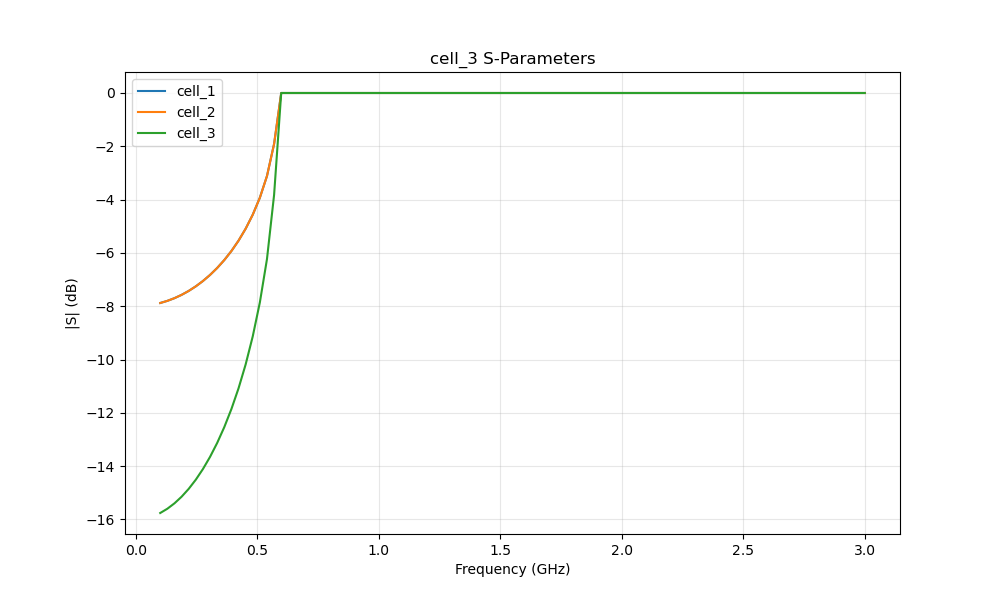

In [7]:
fds.foms.plot_s(['1(1)2(1)'])
plt.show()

In [8]:
roms = fds.foms.reduce()
roms


Model Order Reduction

Domain: cell_1
  Full DOFs: 13392
  Snapshots: 600
  Reduced DOFs: 76
  Compression: 99.4%
  Singular value decay: 2.32e+05 → 2.22e-01

Domain: cell_2
  Full DOFs: 12805
  Snapshots: 600
  Reduced DOFs: 78
  Compression: 99.4%
  Singular value decay: 3.62e+05 → 3.47e-01

Domain: cell_3
  Full DOFs: 20951
  Snapshots: 600
  Reduced DOFs: 127
  Compression: 99.4%
  Singular value decay: 1.74e+05 → 1.61e-01

------------------------------------------------------------
Total: 47148 → 281 DOFs
Overall compression: 99.4%


ROMCollection([cell_1, cell_2, cell_3])

In [9]:
%time roms_concat = roms.concatenate()
%time result = roms_concat.solve(fmin, fmax, 100)
%time roms_concat_rom = roms_concat.reduce()
%time result = roms_concat_rom.solve(fmin, fmax, 1000)
# rom_result = roms.solve(fmin, fmax, 1000)


Coupled system: 281 -> 275 DOFs
External port-modes: 6, Internal port-modes: 12
Port connections: 2 (× 3 modes each)
CPU times: total: 93.8 ms
Wall time: 26.6 ms
  Solver: direct (system size 275)
  Solve loop: 0.279s (100 freq points)
  Z→S conversion: 0.027s
CPU times: total: 438 ms
Wall time: 309 ms

Reduced concatenated system: 275 -> 175 DOFs
Compression: 36.4%
CPU times: total: 922 ms
Wall time: 477 ms
  Solver: direct (system size 175)
  Solve loop: 0.444s (1000 freq points)
  Z→S conversion: 0.259s
CPU times: total: 953 ms
Wall time: 716 ms


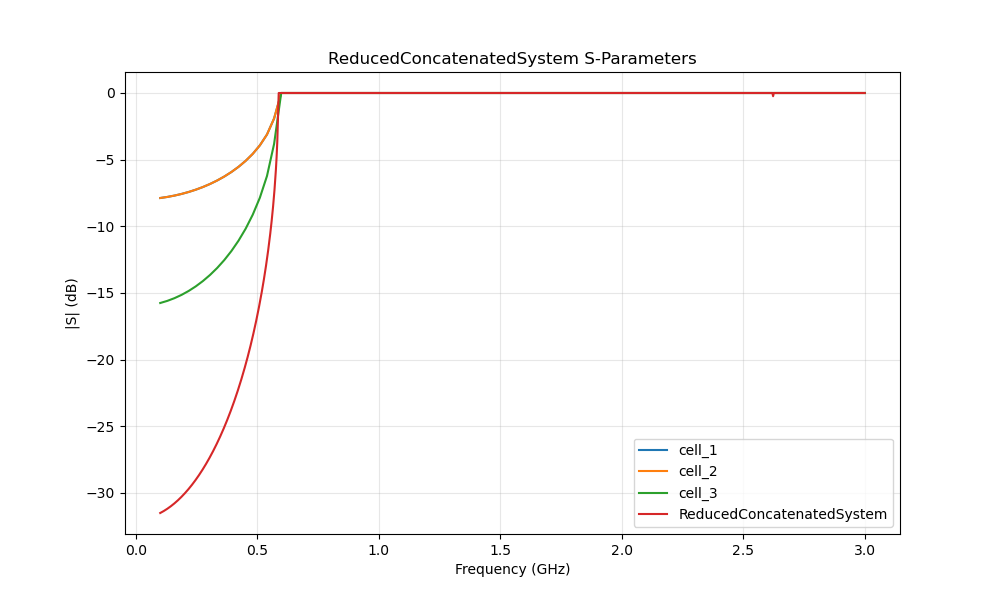

In [10]:
fig, ax = fds.foms.plot_s(['1(1)2(1)'])
# roms.plot_s(['1(1)2(1)'], ax=ax)
roms_concat_rom.plot_s(['1(1)2(1)'], ax=ax)
plt.show()